# Exp 17 — Статистика unified-графа

Читает артефакты из `data/graphs/<tag>/v17_views/`:
- `stats.json` — сводные числа
- `graph.pt` — HeteroData (для распределений степеней)
- `dataset_mappings.json` — какие строки относятся к какому датасету
- `train_pairs.pt` / `val_pairs.pt` / `test_pairs.pt`

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

MODEL_TAG = "bge-m3"
SUBDIR = "v17_views"
GRAPH_DIR = Path("../../data/graphs") / MODEL_TAG / SUBDIR

print("Graph dir:", GRAPH_DIR.resolve())
print("Files:")
for f in sorted(GRAPH_DIR.glob("*")):
    print(f"  {f.name:30s} {f.stat().st_size / 1e6:10.2f} MB")

Graph dir: /home/user/Lysenko/Diplom/TableUnifier/data/graphs/bge-m3/v17_views
Files:
  dataset_mappings.json               55.75 MB
  graph.pt                         17290.81 MB
  stats.json                           0.00 MB
  test_pairs.legacy.pt                18.68 MB
  test_pairs.pt                        2.26 MB
  train_pairs.legacy.pt               87.14 MB
  train_pairs.pt                     119.98 MB
  val_pairs.legacy.pt                 18.67 MB
  val_pairs.pt                         2.26 MB


## 1. Сводные числа из stats.json

In [2]:
stats = json.loads((GRAPH_DIR / "stats.json").read_text())

summary = {
    "rows":           stats["n_rows"],
    "tokens":         stats["n_tokens"],
    "edges":          stats["n_edges"],
    "col_dim":        stats["col_dim"],
    "labeled pairs":  stats["n_labeled"],
    "train pairs":    stats["n_train"],
    "val pairs":      stats["n_val"],
    "test pairs":     stats["n_test"],
    "datasets total": stats["n_datasets"],
    "  magellan":     len(stats["magellan_datasets"]),
    "  exp17":        len(stats["exp17_datasets"]),
    "MRL target_dim": stats["mrl_target_dim"],
}
for k, v in summary.items():
    print(f"  {k:18s} {v:>12,}" if isinstance(v, int) else f"  {k:18s} {v:>12}")

  rows                  3,179,229
  tokens                   55,151
  edges               100,810,972
  col_dim                   1,024
  labeled pairs         5,187,065
  train pairs           4,999,184
  val pairs                93,945
  test pairs               93,936
  datasets total               41
    magellan                   21
    exp17                      20
  MRL target_dim            1,024


## 2. Воронка фильтрации токенов и рёбер

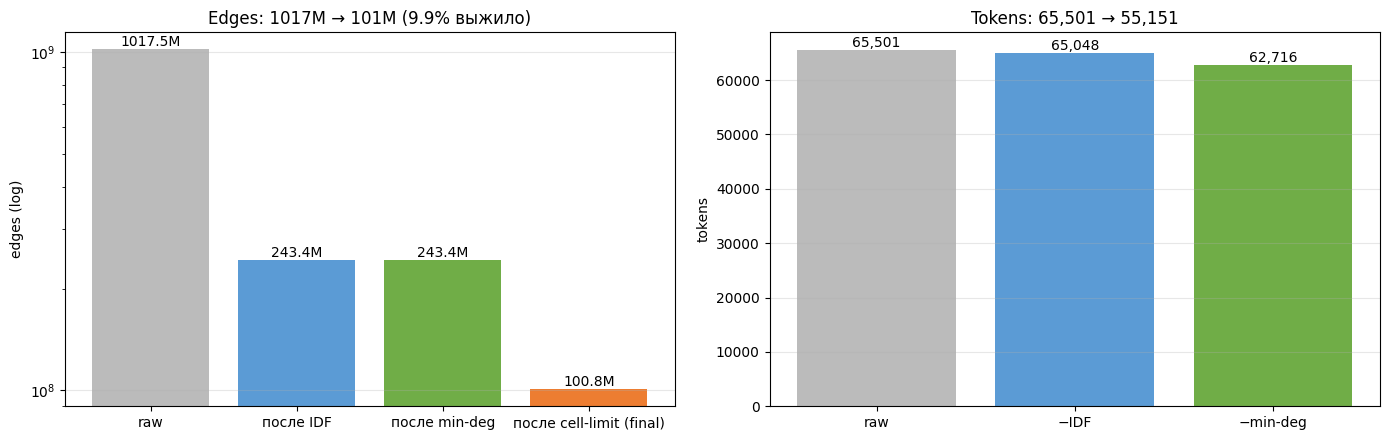


IDF threshold: df > 5.0% строк (выкинуто 453 токенов)
Min token count: df < 2 (выкинуто 2332)
Cell limit отрезал ещё 143M рёбер


In [3]:
fs = stats["filter_stats"]

stages_edges = [
    ("raw",          fs["raw_edges"]),
    ("после IDF",    fs["edges_after_idf"]),
    ("после min-deg",fs["edges_after_idf"] - fs["edges_removed_mindeg"]),
    ("после cell-limit (final)", fs["final_edges"]),
]
stages_tokens = [
    ("raw",         fs["raw_tokens"]),
    ("−IDF",        fs["raw_tokens"] - fs["tokens_removed_idf"]),
    ("−min-deg",    fs["raw_tokens"] - fs["tokens_removed_idf"] - fs["tokens_removed_mindeg"]),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
labels = [s[0] for s in stages_edges]
vals = [s[1] for s in stages_edges]
bars = ax.bar(labels, vals, color=["#bbb", "#5b9bd5", "#70ad47", "#ed7d31"])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v / 1e6:.1f}M",
            ha="center", va="bottom")
ax.set_yscale("log")
ax.set_ylabel("edges (log)")
ax.set_title(f"Edges: {fs['raw_edges']/1e6:.0f}M → {fs['final_edges']/1e6:.0f}M "
             f"({100*fs['final_edges']/fs['raw_edges']:.1f}% выжило)")
ax.grid(alpha=0.3, axis="y")

ax = axes[1]
labels = [s[0] for s in stages_tokens]
vals = [s[1] for s in stages_tokens]
bars = ax.bar(labels, vals, color=["#bbb", "#5b9bd5", "#70ad47"])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}",
            ha="center", va="bottom")
ax.set_ylabel("tokens")
ax.set_title(f"Tokens: {fs['raw_tokens']:,} → {stats['n_tokens']:,}")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"\nIDF threshold: df > {fs['idf_threshold']*100:.1f}% строк (выкинуто {fs['tokens_removed_idf']} токенов)")
print(f"Min token count: df < {fs['min_token_count']} (выкинуто {fs['tokens_removed_mindeg']})")
print(f"Cell limit отрезал ещё {fs['edges_removed_cell_limit']/1e6:.0f}M рёбер")

## 3. Сколько строк / labeled-пар принёс каждый датасет

In [4]:
mappings = json.loads((GRAPH_DIR / "dataset_mappings.json").read_text())

rows_per_ds = {
    name: len(m["id_to_global_a"]) + len(m["id_to_global_b"])
    for name, m in mappings.items()
}

# Пары: маппим global → dataset, считаем
global_to_ds: dict[int, str] = {}
for name, m in mappings.items():
    for g in m["id_to_global_a"].values():
        global_to_ds[g] = name
    for g in m["id_to_global_b"].values():
        global_to_ds[g] = name

train_pairs = torch.load(GRAPH_DIR / "train_pairs.pt", weights_only=False)
val_pairs   = torch.load(GRAPH_DIR / "val_pairs.pt",   weights_only=False)
test_pairs  = torch.load(GRAPH_DIR / "test_pairs.pt",  weights_only=False)

def count_pairs_per_ds(pairs):
    pos = Counter(); neg = Counter()
    for a, b, lbl in pairs.numpy():
        ds = global_to_ds.get(int(a), "?")
        (pos if lbl == 1 else neg)[ds] += 1
    return pos, neg

tr_pos, tr_neg = count_pairs_per_ds(train_pairs)
va_pos, va_neg = count_pairs_per_ds(val_pairs)
te_pos, te_neg = count_pairs_per_ds(test_pairs)

df = pd.DataFrame({
    "rows":      pd.Series(rows_per_ds),
    "train+":    pd.Series(tr_pos), "train−": pd.Series(tr_neg),
    "val+":      pd.Series(va_pos), "val−":   pd.Series(va_neg),
    "test+":     pd.Series(te_pos), "test−":  pd.Series(te_neg),
}).fillna(0).astype(int)
df["total pairs"] = df[["train+", "train−", "val+", "val−", "test+", "test−"]].sum(axis=1)
df = df.sort_values("total pairs", ascending=False)
df

,rows,train+,train−,val+,val−,test+,test−,total pairs
cars_ru_v0v1,200000,99996,500000,2,0,2,0,600000
cars_ru_v0v2,200000,100000,500000,0,0,0,0,600000
cars_ru_v0v3,200000,99993,500000,4,0,3,0,600000
cars_ru_v2v3,200000,99994,500000,3,0,3,0,600000
cars_ru_v1v3,200000,99998,500000,1,0,1,0,600000
cars_ru_v1v2,200000,99997,500000,2,0,1,0,600000
ozon_syn2,231907,29037,152287,2189,7391,2188,7392,200484
ozon_syn3,231907,29087,152265,2151,7415,2176,7390,200484
ozon_syn0,231907,28963,152144,2232,7457,2219,7469,200484
ozon_syn1,231907,29071,152535,2144,7295,2199,7240,200484


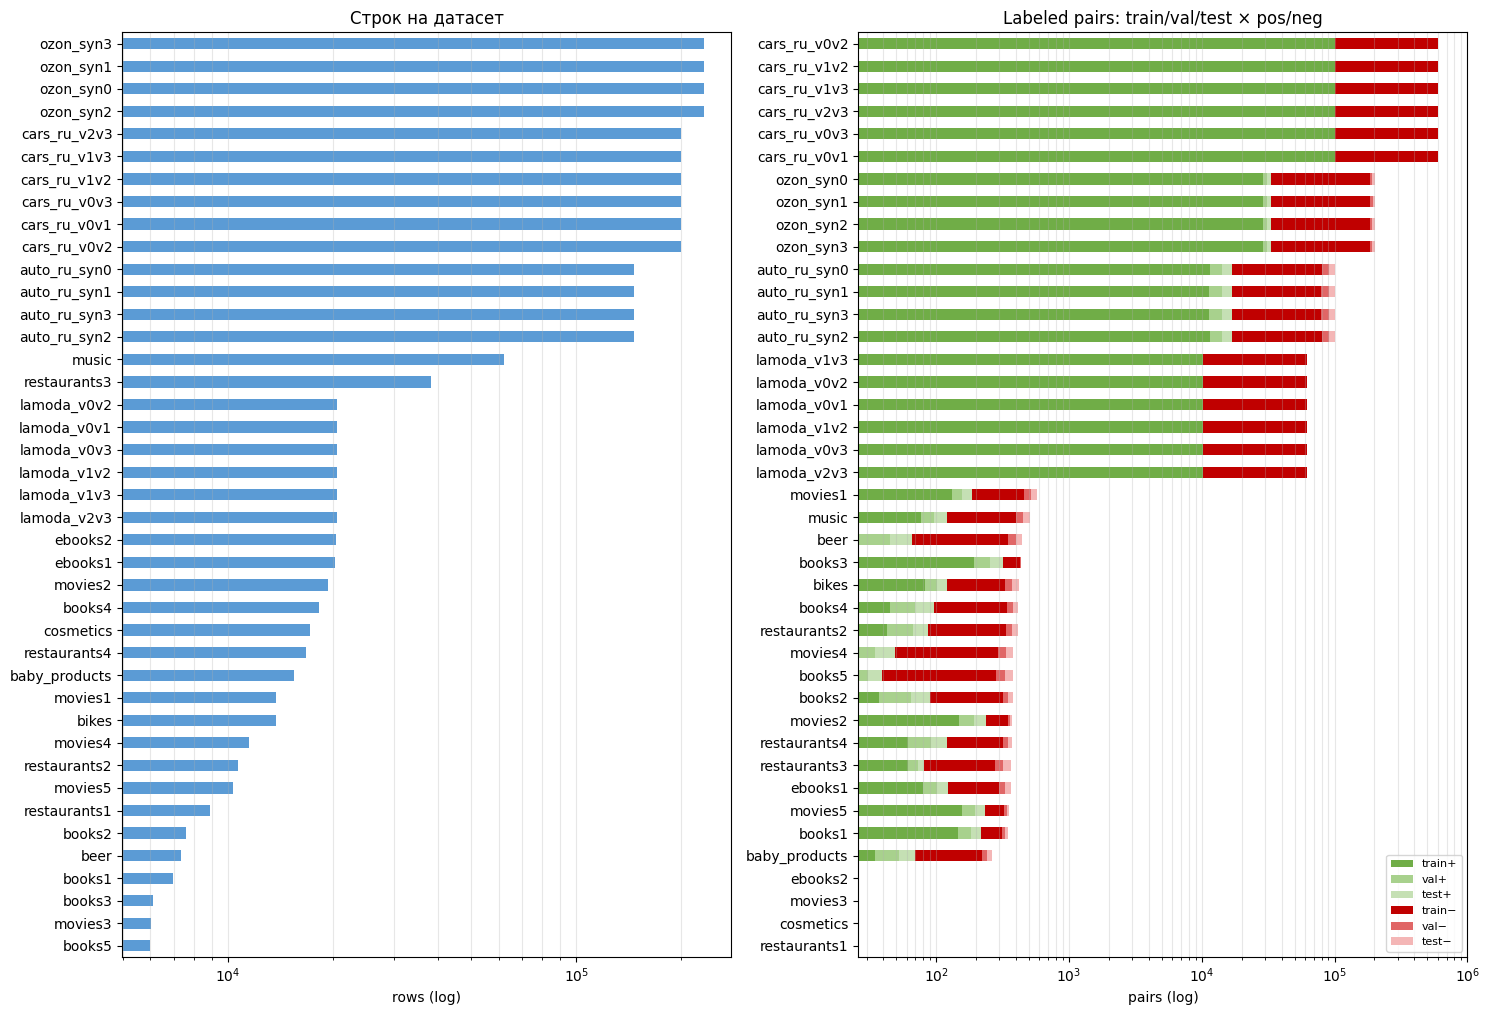

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(6, len(df) * 0.25)))

ax = axes[0]
df["rows"].sort_values().plot.barh(ax=ax, color="#5b9bd5")
ax.set_xscale("log")
ax.set_xlabel("rows (log)")
ax.set_title("Строк на датасет")
ax.grid(alpha=0.3, axis="x", which="both")

ax = axes[1]
pair_cols = ["train+", "val+", "test+", "train−", "val−", "test−"]
df_sorted = df.sort_values("total pairs")
df_sorted[pair_cols].plot.barh(ax=ax, stacked=True,
    color=["#70ad47", "#a8d18d", "#c5e0b4", "#c00000", "#e06666", "#f4b6b6"])
ax.set_xscale("log")
ax.set_xlabel("pairs (log)")
ax.set_title("Labeled pairs: train/val/test × pos/neg")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3, axis="x", which="both")

plt.tight_layout()
plt.show()

## 4. Распределение степеней узлов в графе

⚠️ Загрузка `graph.pt` — это ~13GB+ в память. Если работаешь на ноуте — пропусти эту секцию или копируй граф локально через rclone.

In [6]:
LOAD_GRAPH = True  # поставь False, если оперативки мало

if LOAD_GRAPH:
    graph = torch.load(GRAPH_DIR / "graph.pt", weights_only=False)
    print(graph)
else:
    graph = None

/home/user/Lysenko/Diplom/TableUnifier/.venv/lib/python3.12/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /home/user/Lysenko/Diplom/TableUnifier/.venv/lib/python3.12/site-packages/torch_sparse/_version_cuda.so
  import torch_geometric.typing


HeteroData(
  col_embeddings=[2526, 1024],
  filter_stats={
    raw_tokens=65501,
    raw_edges=1017480373,
    idf_threshold=0.05,
    min_token_count=2,
    tokens_removed_idf=453,
    tokens_removed_mindeg=2332,
    edges_removed_idf=774117818,
    edges_removed_mindeg=2399,
    edges_after_idf=243362555,
    edges_removed_cell_limit=142549184,
    final_tokens=55151,
    final_edges=100810972,
  },
  row={ x=[3179229, 1024] },
  token={ x=[55151, 1024] },
  (token, in_row, row)={
    edge_index=[2, 100810972],
    edge_col_idx=[100810972],
  },
  (row, has_token, token)={
    edge_index=[2, 100810972],
    edge_col_idx=[100810972],
  }
)


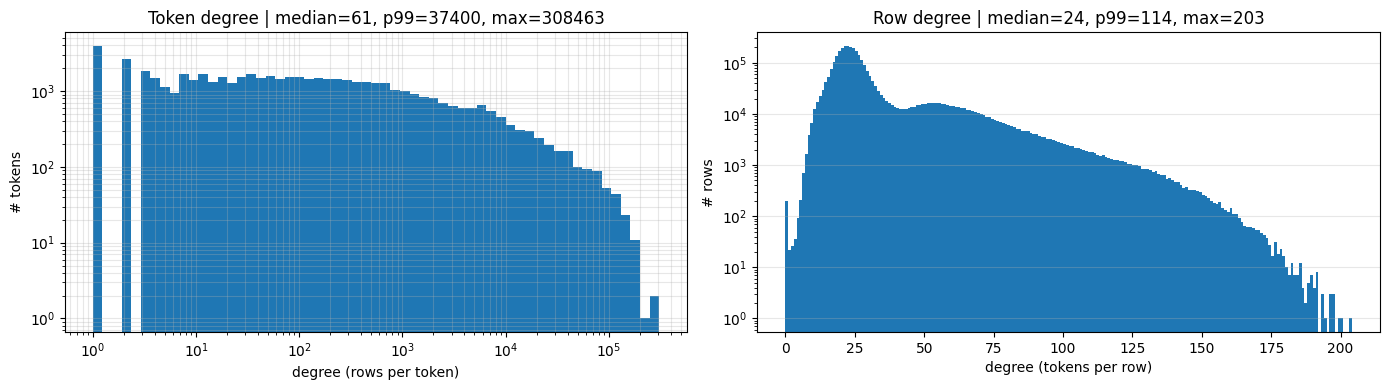

Изолированных row-узлов (без рёбер): 200 / 3,179,229
Изолированных token-узлов: 0 / 55,151


In [7]:
if graph is not None:
    edge_index = graph["token", "in_row", "row"].edge_index
    token_src = edge_index[0].numpy()
    row_dst   = edge_index[1].numpy()
    n_tokens  = graph["token"].x.shape[0]
    n_rows    = graph["row"].x.shape[0]

    token_deg = np.bincount(token_src, minlength=n_tokens)
    row_deg   = np.bincount(row_dst,   minlength=n_rows)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.hist(token_deg, bins=np.logspace(0, np.log10(token_deg.max() + 1), 60))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("degree (rows per token)"); ax.set_ylabel("# tokens")
    ax.set_title(f"Token degree | median={int(np.median(token_deg))}, "
                 f"p99={int(np.percentile(token_deg, 99))}, "
                 f"max={token_deg.max()}")
    ax.grid(alpha=0.3, which="both")

    ax = axes[1]
    ax.hist(row_deg, bins=np.arange(0, row_deg.max() + 2))
    ax.set_yscale("log")
    ax.set_xlabel("degree (tokens per row)"); ax.set_ylabel("# rows")
    ax.set_title(f"Row degree | median={int(np.median(row_deg))}, "
                 f"p99={int(np.percentile(row_deg, 99))}, "
                 f"max={row_deg.max()}")
    ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

    print(f"Изолированных row-узлов (без рёбер): {(row_deg == 0).sum():,} / {n_rows:,}")
    print(f"Изолированных token-узлов: {(token_deg == 0).sum():,} / {n_tokens:,}")

## 5. Cross-domain графы (electronics / anime / citations)

In [8]:
cross_dir = Path("../../data/graphs") / MODEL_TAG / f"{SUBDIR}_cross"
if cross_dir.exists():
    rows = []
    for ds_dir in sorted(cross_dir.iterdir()):
        g_path = ds_dir / "graph.pt"
        pairs_path = ds_dir / "labeled_pairs.pt"
        if not g_path.exists():
            continue
        g = torch.load(g_path, weights_only=False)
        n_pairs = 0
        if pairs_path.exists():
            p = torch.load(pairs_path, weights_only=False)
            n_pairs = len(p)
        rows.append({
            "dataset": ds_dir.name,
            "rows":    g["row"].x.shape[0],
            "tokens":  g["token"].x.shape[0],
            "edges":   g["token", "in_row", "row"].edge_index.shape[1],
            "pairs":   n_pairs,
        })
    pd.DataFrame(rows).set_index("dataset")
else:
    print(f"{cross_dir} не существует — пропуск")